# PCA part
after: https://towardsdatascience.com/pca-using-python-scikit-learn-e653f8989e60

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"# load dataset into Pandas DataFrame
df = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])
features = ['sepal length', 'sepal width', 'petal length', 'petal width']
# Separating out the features
x = df.loc[:, features].values# Separating out the target
y = df.loc[:,['target']].values# Standardizing the features
x = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, df[['target']]], axis = 1)
finalDf
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()
#Variation explained
print(pca.explained_variance_ratio_)
np.sum(pca.explained_variance_ratio_)

## On the Centerline Dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [34]:
#path='/groups/zimmer/Ulises/code/skeleton_OLD/spline/second_der_np_new.csv'
#path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/2new_spline_K.csv'#
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-10-48_control_worm1_spline_K.csv'
# has no reversals path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_18-17-47_chemotaxis_worm5_spline_K.csv'
df=pd.read_csv(path, header=None)

df.shape
df.dropna(inplace=True) #Drop NaNs, required otherwise pca.fit_transform(x) does not run
df.fillna(0, inplace=True) #alternative change nans to zeros
features = np.arange(30,95)# Separating out the features (starting bodypart, ending bodypart)
data = df.loc[:, features].values
print('data shape: ', data.shape)

#PCA
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(data)
print(principalComponents.shape)
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2', 'PC3','PC4','PC5'])# 'PC6', 'PC7', 'PC8','PC9','PC10'])

data shape:  (137785, 65)
(137785, 5)


Text(0, 0.5, '')

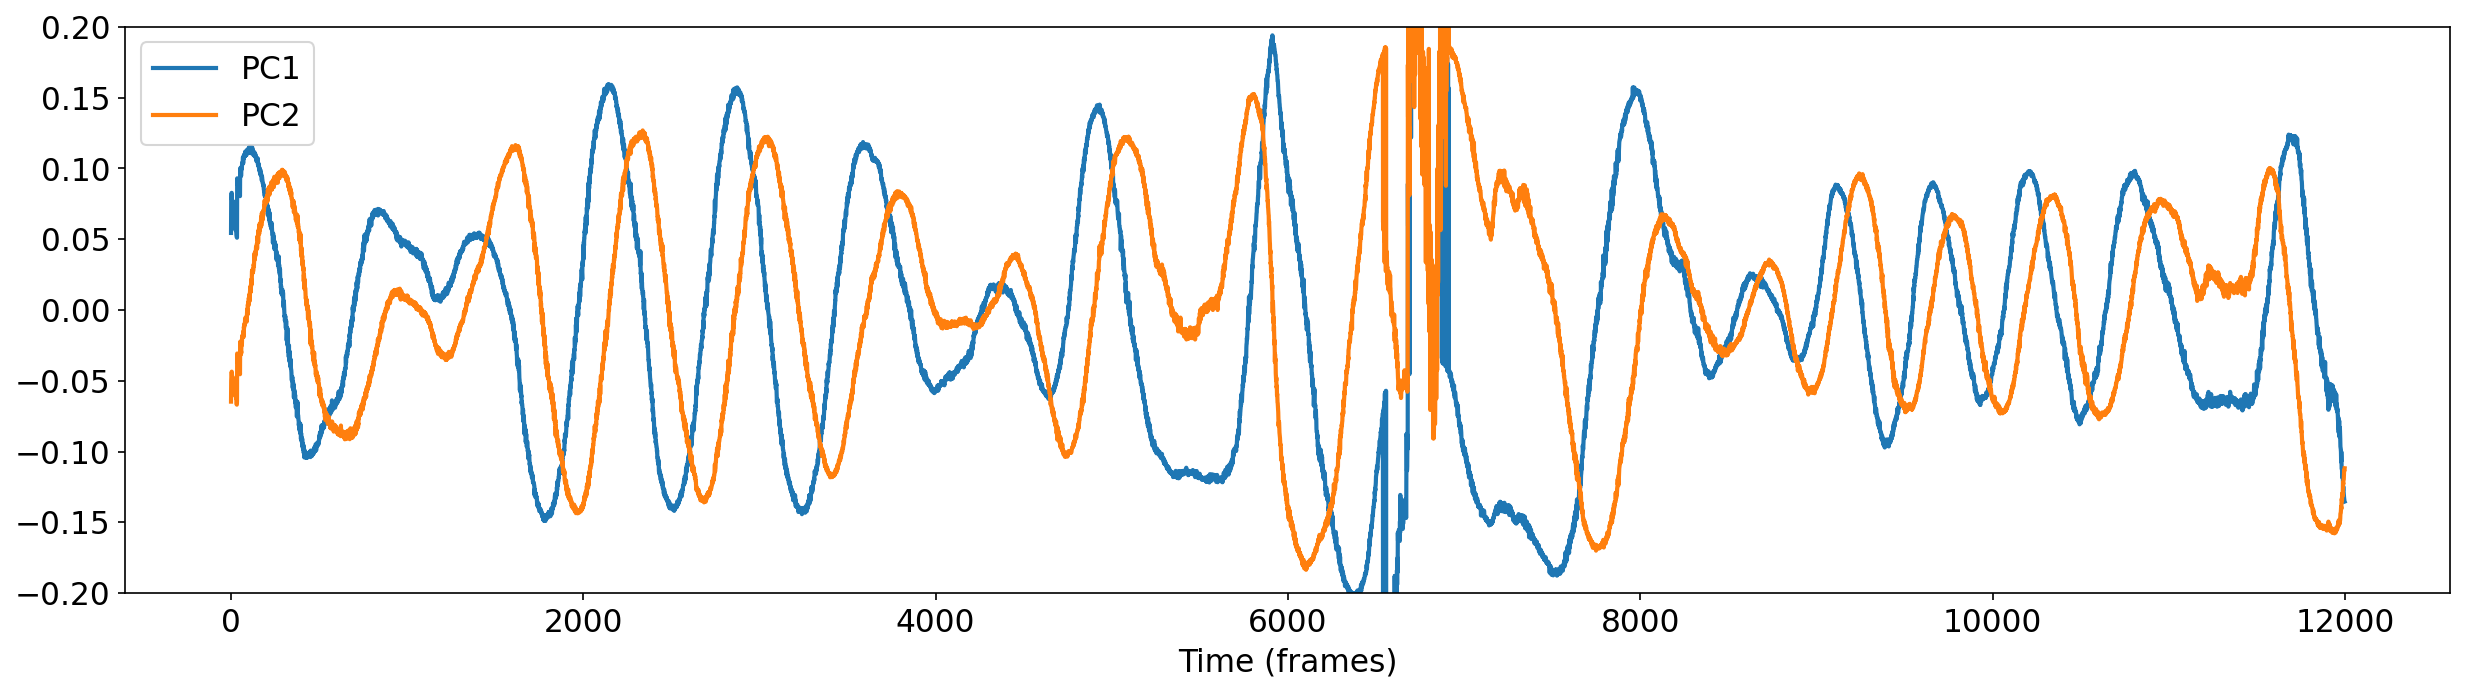

In [35]:
time=np.arange(12000)#(142465)#(20000,30000)#np.arange(18000,42000)#np.arange(57500,62000)#np.arange(18000,42000)
plt.figure(dpi=150)
plt.rcParams.update({'font.size': 15})
for pc in principalDf:
    if pc is 'PC3': break
    ax=principalDf.loc[time,pc].plot(legend=True, figsize=(20,5), linewidth=2)
ax.set_xlabel('Time (frames)', fontsize = 15)
ax.set_ylim([-.2,.2])
ax.set_ylabel('',fontsize = 15)

In [4]:
principalDf.head(10)
#pc1Xpc2=pd.DataFrame(np.cross(principalDf['PC1'],principalDf['PC2']), index=principalDf.index)

,PC1,PC2,PC3,PC4,PC5
0,0.054408,-0.064746,-0.128852,-0.013302,0.001225
1,0.077069,-0.049986,-0.119308,-0.039031,0.011940
2,0.079615,-0.046881,-0.116150,-0.041909,0.012109
3,0.082660,-0.044533,-0.114962,-0.043675,0.012765
4,0.082733,-0.043585,-0.112456,-0.041638,0.009953
5,0.077832,-0.044754,-0.116988,-0.040064,0.010512
6,0.077633,-0.047330,-0.117227,-0.040802,0.011731
7,0.075329,-0.049719,-0.120494,-0.037825,0.011028
8,0.077108,-0.047526,-0.118459,-0.037386,0.009470
9,0.076021,-0.047348,-0.119578,-0.039537,0.012374


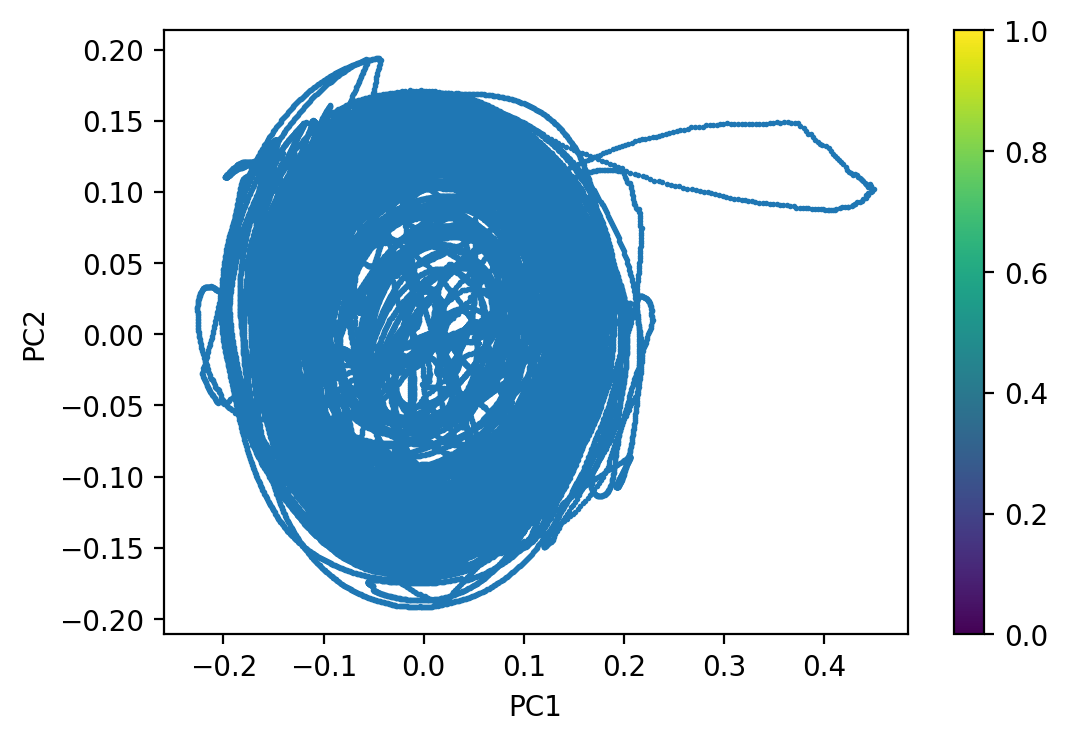

In [25]:
#without a color
plt.rcParams.update({'font.size': 10})

#time=np.arange(18000,42000)#np.arange(10000,14000)
avg_win=150
x=principalDf.loc[:,'PC1'].rolling(window=avg_win).mean()
y=principalDf.loc[:,'PC2'].rolling(window=avg_win).mean()
plt.figure(dpi=200)
plt.scatter(x,y, s=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.show()

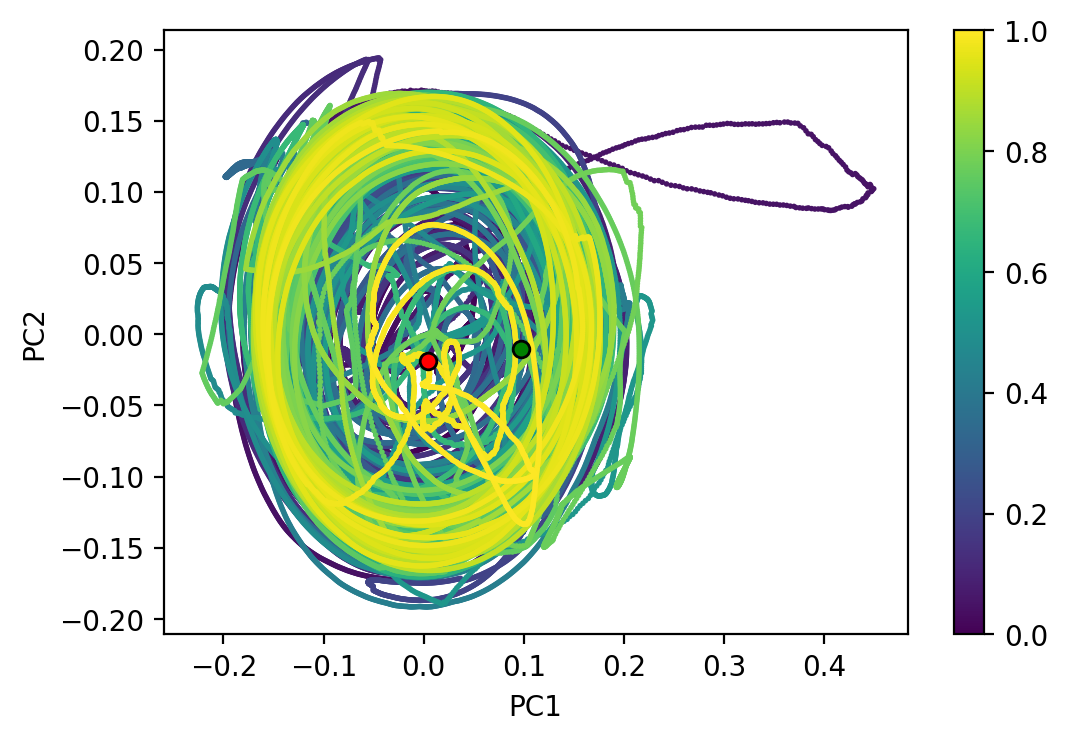

In [26]:
plt.rcParams.update({'font.size': 10})

x=principalDf.loc[time,'PC1'].rolling(window=avg_win).mean()
y=principalDf.loc[time,'PC2'].rolling(window=avg_win).mean()
plt.figure(dpi=200)
plt.scatter(x,y, c=np.arange(len(x)), s=1, cmap='viridis')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g', edgecolors='k')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r', edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
#lim=0.05#0.25
# plt.xlim([-lim, lim])
# plt.ylim([-lim, lim])
plt.colorbar()


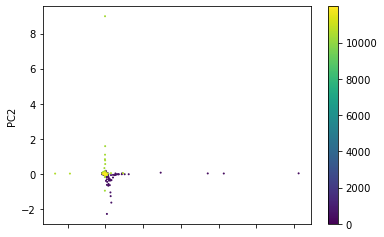

In [8]:
ax=principalDf.loc[time,:].plot.scatter(x='PC1', y='PC2', s=1, c=time, colormap='viridis')#c=principalDf.index
plt.rcParams["figure.dpi"] = 250
#principalDf.loc[0,:].plot(x='PC1', y='PC2', c='k', ax=ax, linewidth=0.0001)#c=principalDf.index

In [8]:
print(type(principalDf.loc[1,:]))
#.plot.scatter(x='PC1', y='PC2')

<class 'pandas.core.series.Series'>


In [36]:
#create crossproduct dataframe from series
frame = { 'X': x, 'Y': y } 
cross_product_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.array(np.nan)]#before was np.nan
for i, row in enumerate(cross_product_df.iterrows()):
    if i==len(cross_product_df)-1: continue
    r=np.cross([cross_product_df['X'].values[i],cross_product_df['Y'].values[i]], [cross_product_df['X'].values[i+1],cross_product_df['Y'].values[i+1]])
    
    ra.append(r)
#write the list ra into cross_product_df, column 'Cors Product'    
cross_product_df['Cross Product']=ra



In [37]:
values = [float(value) for value in cross_product_df['Cross Product'].values]

In [38]:
values_arr=np.array(values)

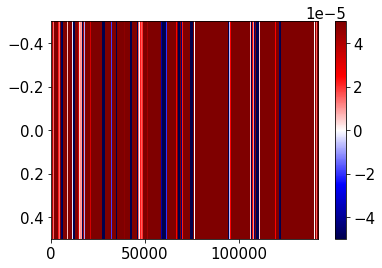

In [39]:
plt.imshow(values_arr.reshape(1,-1),origin="upper",cmap='seismic', aspect='auto', vmin=-0.00005, vmax=0.00005)
plt.colorbar()

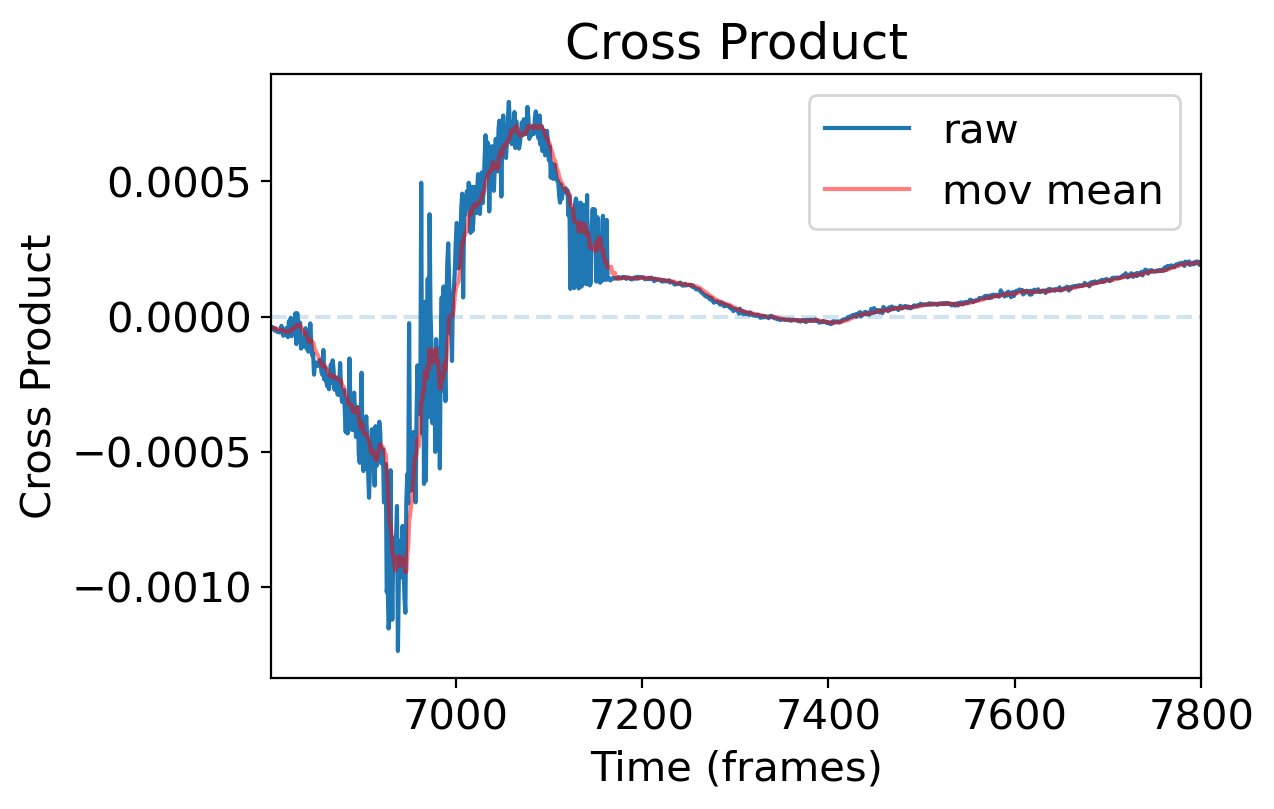

In [44]:

#optional plotting
plt.figure(dpi=200)
plt.plot(cross_product_df.loc[time,'Cross Product'], label='raw')
plt.plot(cross_product_df.loc[time,'Cross Product'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
#plt.ylim([-0.000025, 0.000025])
plt.axhline(y=0, xmin=0, xmax=14000, alpha=0.2, linestyle='--')
plt.title('Cross Product')
plt.ylabel('Cross Product')
plt.xlabel('Time (frames)')
#lim=0.00005#0.25

#plt.ylim([-lim, lim])
plt.xlim([6802, 7800])
plt.legend()

Text(0, 0.5, 'PC2')

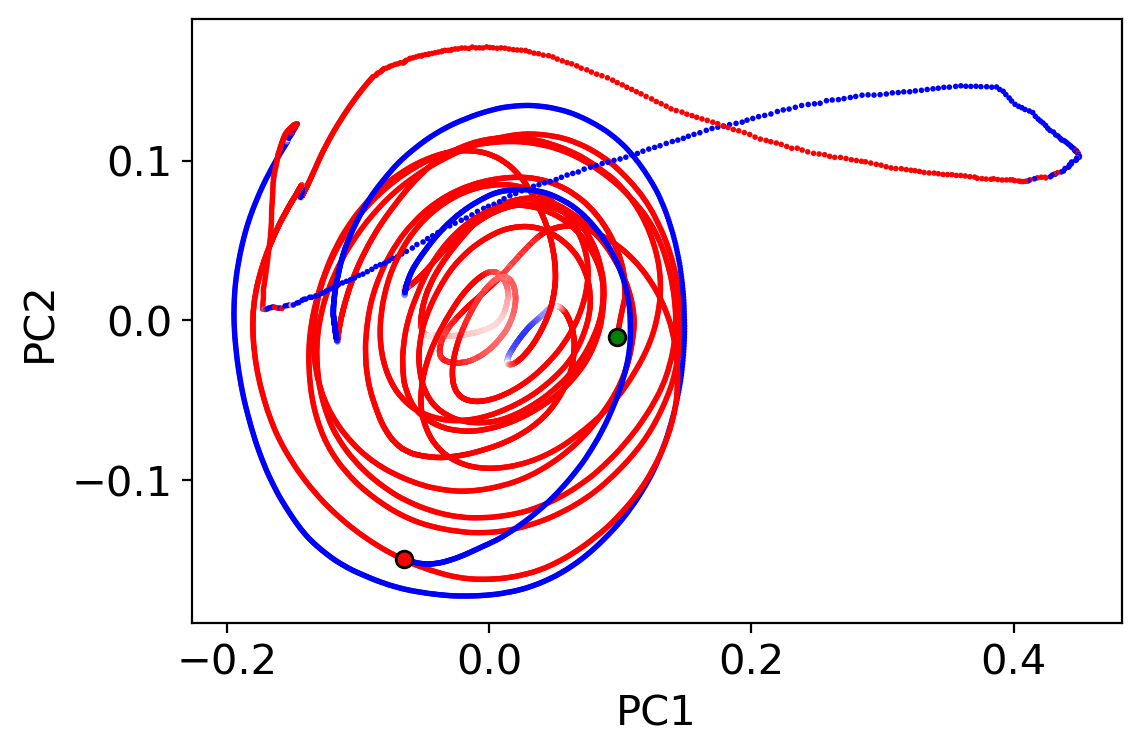

In [18]:
plt.figure(dpi=200)
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g', edgecolor='k')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
#lim=0.05#0.25
#plt.xlim([-lim, lim])
#plt.ylim([-lim, lim])

In [13]:
#Angle Between vectors
#source: https://stackoverflow.com/questions/2827393/angles-between-two-n-dimensional-vectors-in-python

import numpy as np
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))


In [14]:
#create angle difference dataframe from series
frame = { 'X': x, 'Y': y } 
angle_diff_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.nan]
for i, row in enumerate(angle_diff_df.iterrows()):
    if i==len(angle_diff_df)-1: continue
    r=angle_between((angle_diff_df['X'].values[i],angle_diff_df['Y'].values[i]), (angle_diff_df['X'].values[i+1],angle_diff_df['Y'].values[i+1]))
    
    ra.append(r)
angle_diff_df['Angle Diff']=ra



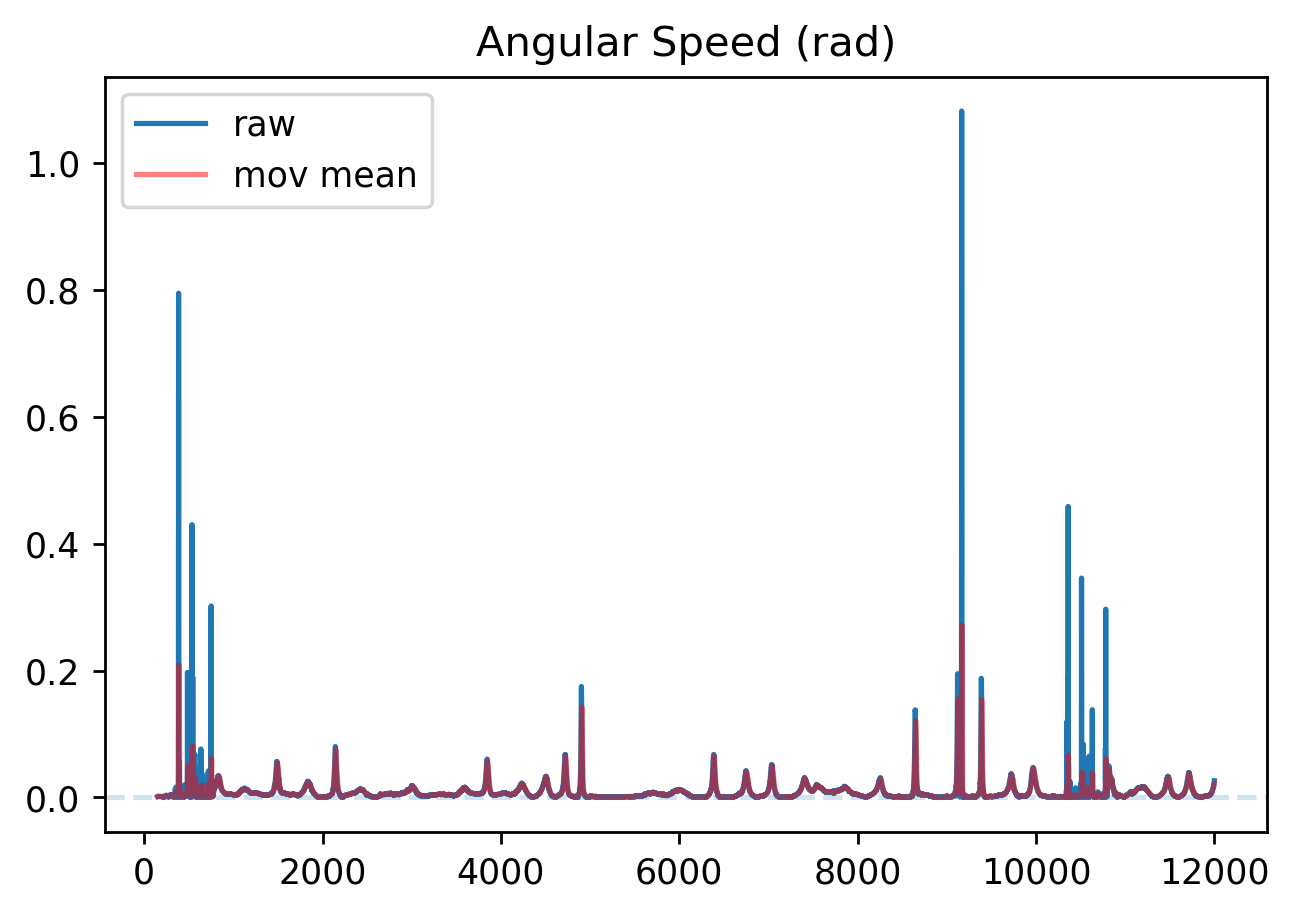

In [15]:
#optional plotting
plt.plot(angle_diff_df.loc[time,'Angle Diff'], label='raw')
plt.plot(angle_diff_df.loc[time,'Angle Diff'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.axhline(y=0, xmin=0, xmax=14000, alpha=0.2, linestyle='--')
plt.title('Angular Speed (rad)')
plt.legend()

In [21]:
#create SIGNED angle difference dataframe from series
frame = { 'X': x, 'Y': y } 
angle_diff_sig_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.nan]
for i, row in enumerate(angle_diff_sig_df.iterrows()):
    if i==len(angle_diff_sig_df)-1: continue
    r=angle_between((angle_diff_sig_df['X'].values[i],angle_diff_sig_df['Y'].values[i]), (1,0))
    
    ra.append(r)
angle_diff_sig_df['Angle Diff']=ra

In [22]:
v1=angle_diff_sig_df['X'].values[i]
v2=angle_diff_sig_df['Y'].values[i]
print(v1)
print(v2)

-0.0078515138396785
-0.0002867088157903495


In [23]:
angle_diff_sig_df

,X,Y,Angle Diff
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
11995,-0.008750,0.000512,3.062053
11996,-0.008513,0.000309,3.083160
11997,-0.008300,0.000112,3.105327
11998,-0.008076,-0.000084,3.128139


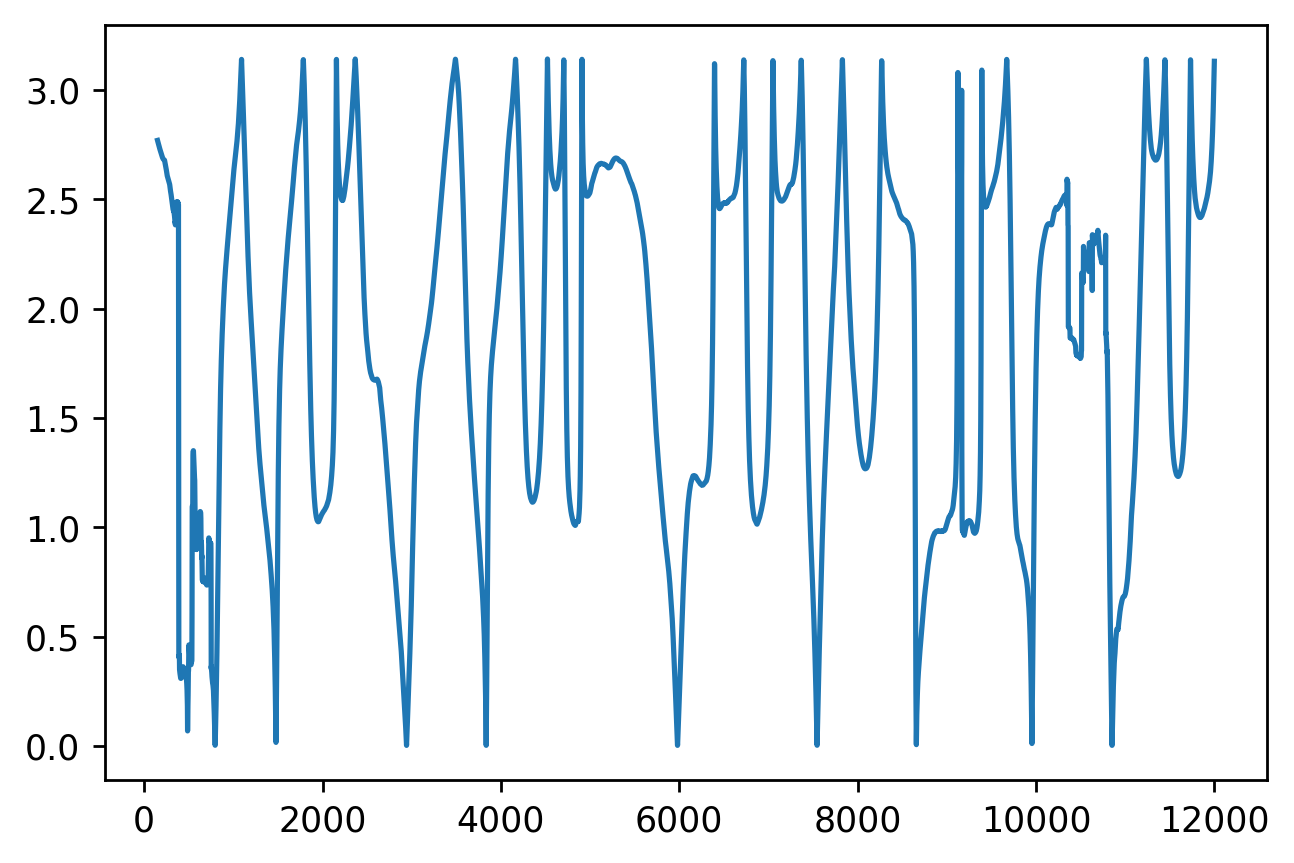

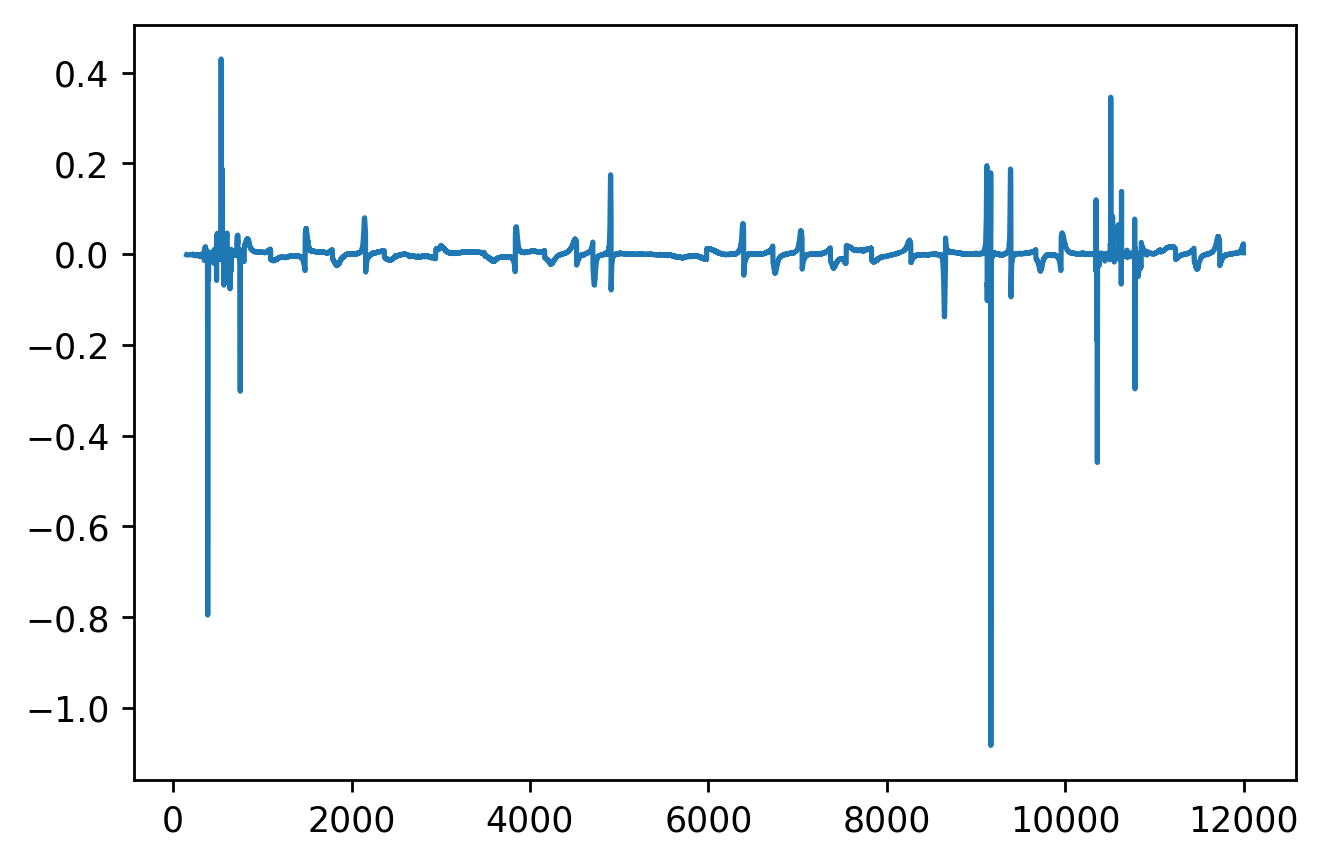

In [24]:
angle_diff_sig_df.loc[time,'Angle Diff'].plot()
plt.show()
ax=angle_diff_sig_df.loc[time,'Angle Diff'].diff().plot()

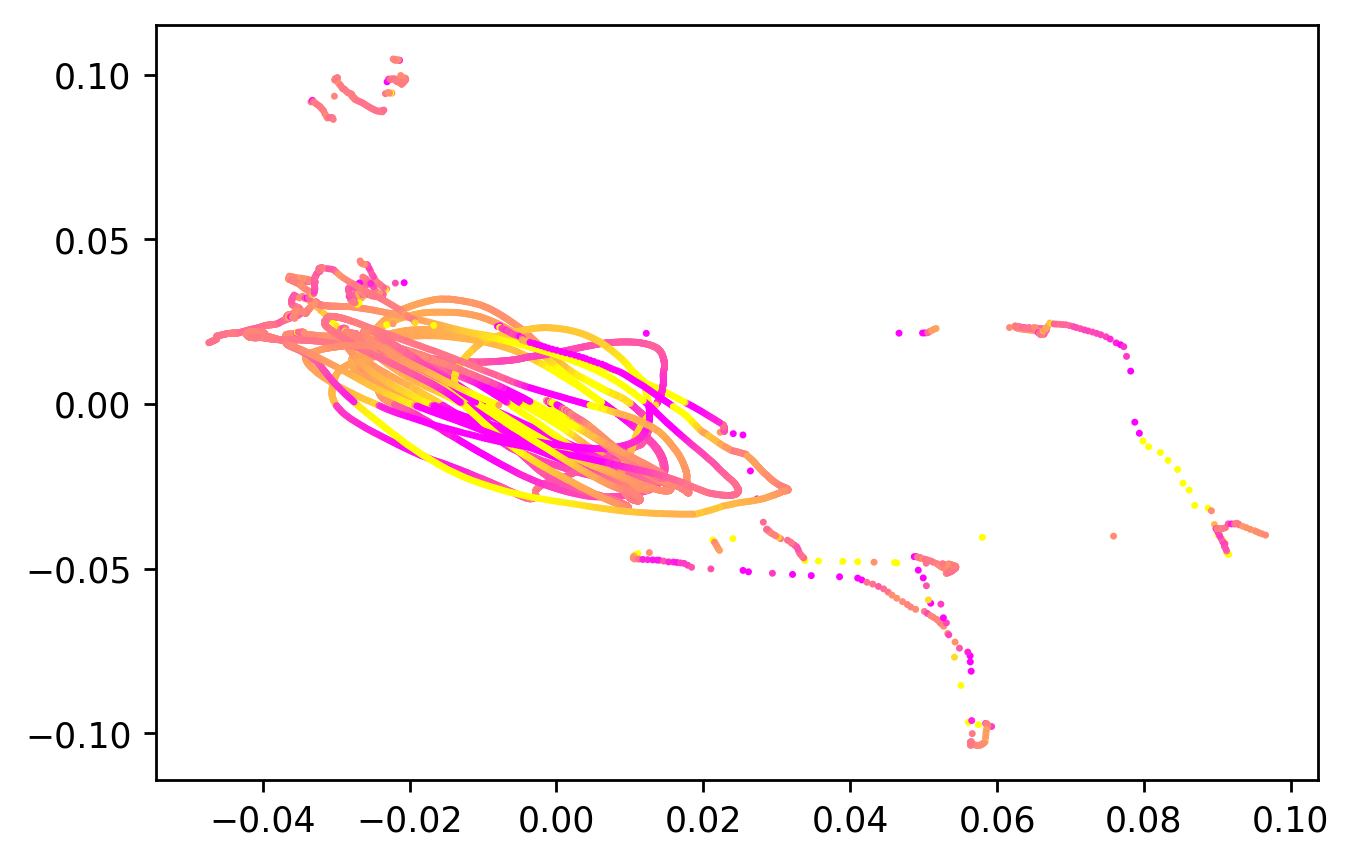

In [25]:
#new_time=np.arange(26000,30000)
x1=principalDf.loc[time,'PC1'].rolling(window=avg_win).mean()
y1=principalDf.loc[time,'PC2'].rolling(window=avg_win).mean()
plt.scatter(x1,y1, c=angle_diff_sig_df.loc[time,'Angle Diff'].diff(), vmin=-0.015, vmax=0.015, s=1, cmap='spring')

Text(0.5, 0, 'Angular Speed (rad)')

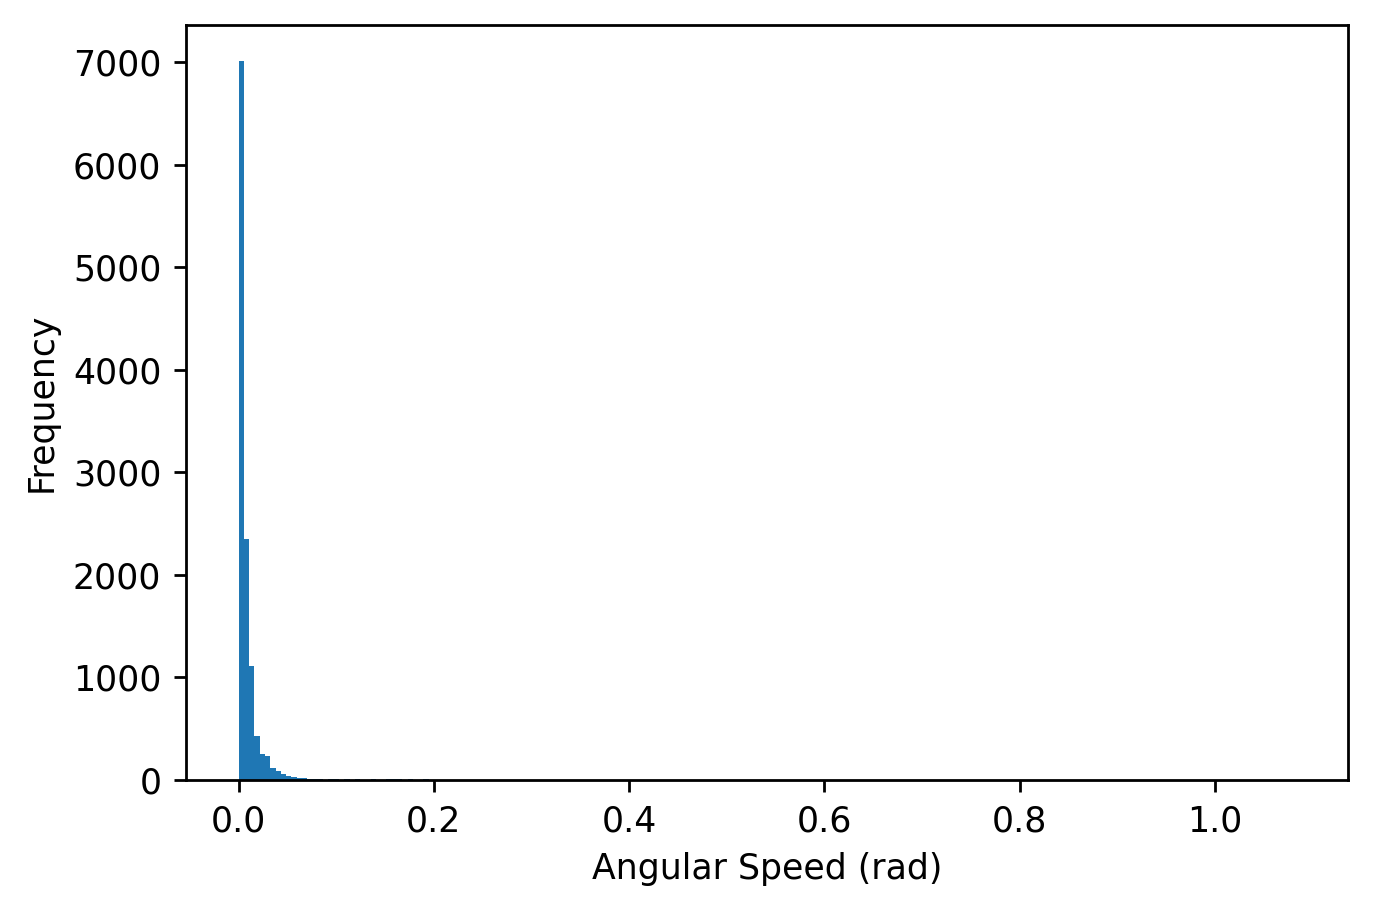

In [26]:
angle_diff_df.loc[:,'Angle Diff'].plot.hist(bins=200)
plt.xlabel('Angular Speed (rad)')

In [28]:
cross_product_df.loc[time,'Cross Product'].plot.hist(bins=100)

TypeError: no numeric data to plot

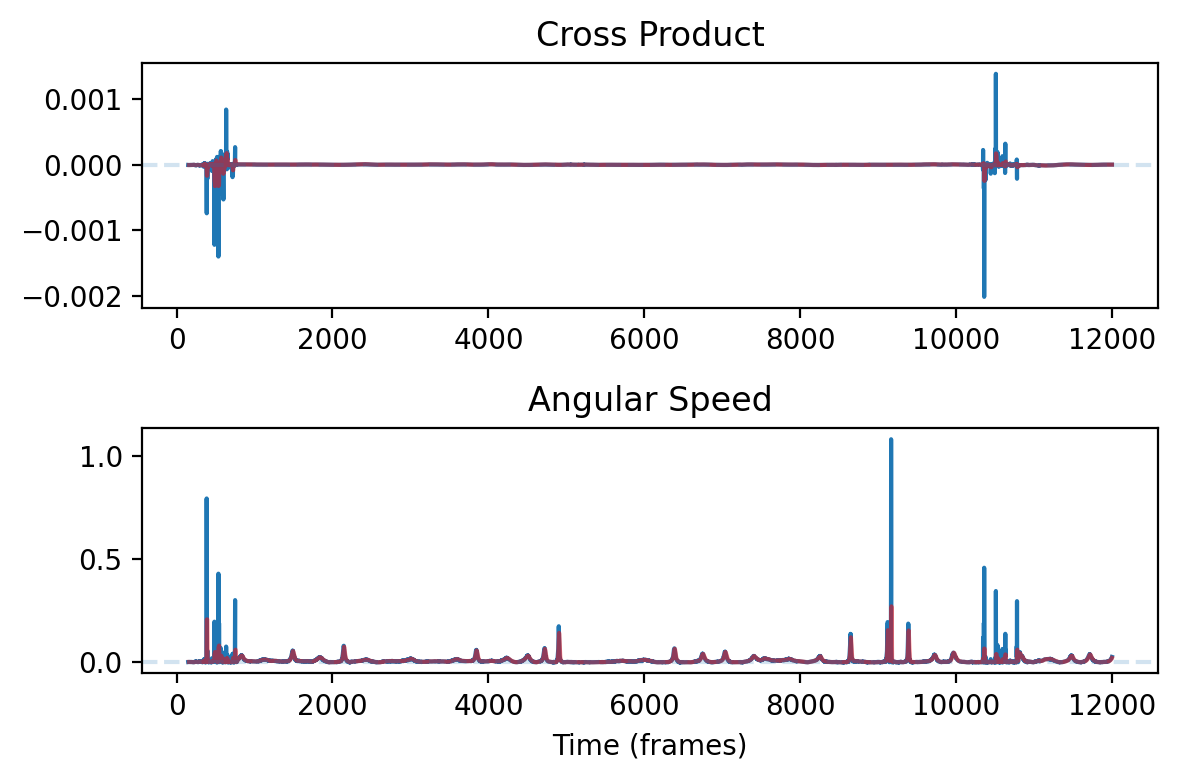

In [38]:
fig=plt.figure(dpi=200)
plt.subplot(2,1,1)
plt.plot(cross_product_df.loc[time,'Cross Product'], label='raw')
plt.plot(cross_product_df.loc[time,'Cross Product'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.axhline(y=0, xmin=0, xmax=14000, alpha=0.2, linestyle='--')
plt.title('Cross Product')
#plt.legend()
plt.subplot(2,1,2)
plt.plot(angle_diff_df.loc[time,'Angle Diff'], label='raw')
plt.plot(angle_diff_df.loc[time,'Angle Diff'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.axhline(y=0, xmin=0, xmax=14000, alpha=0.2, linestyle='--')
plt.title('Angular Speed')
plt.xlabel('Time (frames)')
#plt.legend()
plt.tight_layout()

In [ ]:
y.values[150]

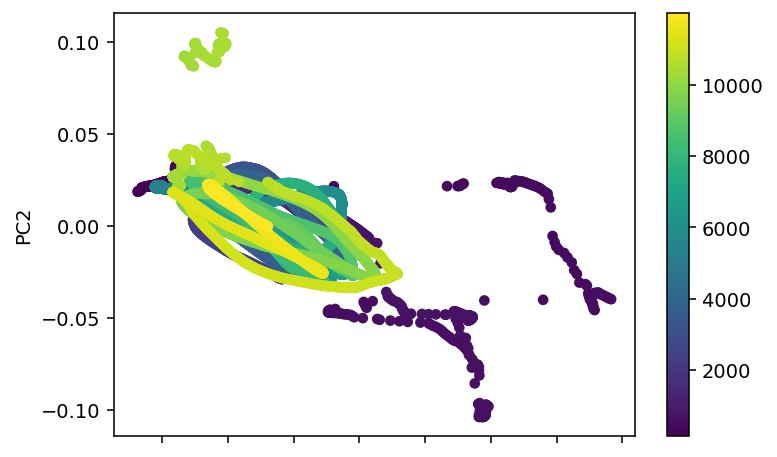

In [11]:
avg_principalDf=pd.DataFrame()
avg_win=150
avg_principalDf=principalDf.rolling(window=avg_win).mean()
x='PC1'
y='PC2'
t_range=np.arange(12000)#(20000,30000)#np.arange(18000,22000)
plt.rcParams["figure.dpi"] = 140
avg_principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c=t_range, colormap='viridis')#c=principalDf.index
#ax.set_xlabel('PC1')
#ax.show()
#ax.set_ylabel("y label")

In [ ]:
plt.rcParams["figure.dpi"] = 250
ax=principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c=t_range, colormap='viridis')#c=principalDf.index
avg_principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c='k', ax=ax, linewidth=0.0001)#c=principalDf.index

ValueError: 'c' argument has 12000 elements, which is inconsistent with 'x' and 'y' with size 12020.

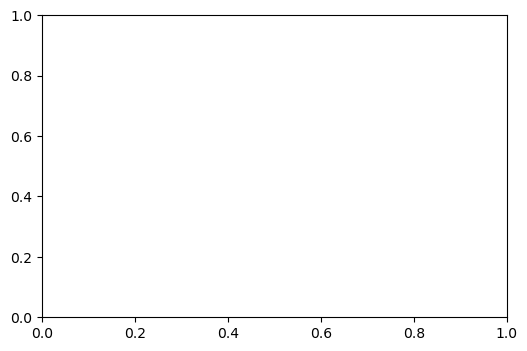

In [14]:
##Animations
from IPython.display import clear_output

#time=np.arange(18000,42000)#np.arange(10000,14000)
avg_win=75
x=principalDf.loc[:,'PC1'].rolling(window=avg_win).mean()
y=principalDf.loc[:,'PC2'].rolling(window=avg_win).mean()

for t in time:
    #print(t)
    
    if t<avg_win: continue
    if t%20!=0: continue
    #print(time[0])
    #print(t)    
    fig=plt.figure(dpi=100)
    
    #with cross product color
    plt.scatter(x[time[0]:t+200],y[time[0]:t+200], c=-1*cross_product_df.loc[time[0]:t+199,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr', alpha=0.1)
    plt.scatter(x[t:t+200],y[t:t+200], c=-1*cross_product_df.loc[t:t+199,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
    #without
    #plt.scatter(x[time[0]:t+200],y[time[0]:t+200], s=1, cmap='viridis', alpha=0.1)
    #plt.scatter(x[t:t+200],y[t:t+200], s=1, cmap='viridis')
    
    plt.scatter(x[t+200],y[t+200], s=10, c='k')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.xlim([-0.25, 0.25])
    plt.ylim([-0.25, 0.25])
    plt.colorbar()
    plt.show()
    fig.savefig('pc_plot_good/PC_'+str(t)+'.png')
    plt.close(fig)
    clear_output(wait=True)
    if t>12000: break


In [ ]:
#With Worm image (does not work yet)
from IPython.display import clear_output

##Animations
#time=np.arange(18000,42000)#np.arange(10000,14000)
avg_win=150
x=principalDf.loc[:,'PC1'].rolling(window=avg_win).mean()
y=principalDf.loc[:,'PC2'].rolling(window=avg_win).mean()

fig, f_axs = plt.subplots(ncols=2, nrows=1, constrained_layout=False, figsize=(10,5), dpi=100)

#     f_axs[i].plot(eigenworm)
#     f_axs[i].set_title('Eigenworm ' +str(i+1))

for t in time:
    #print(t)
    
    if t<avg_win: continue
    if t%25!=0: continue
    #print(time[0])
    #print(t)    
    
    #with cross product color
    
    f_axs[0].scatter(x[time[0]:t+200],y[time[0]:t+200], c=cross_product_df.loc[time[0]:t+199,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr', alpha=0.1)
    f_axs[0].scatter(x[t:t+200],y[t:t+200], c=cross_product_df.loc[t:t+199,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
    #without
    #plt.scatter(x[time[0]:t+200],y[time[0]:t+200], s=1, cmap='viridis', alpha=0.1)
    #plt.scatter(x[t:t+200],y[t:t+200], s=1, cmap='viridis')
    
    f_axs[0].scatter(x[t+200],y[t+200], s=10, c='k')

    f_axs[0].set_xlabel('PC1')
    f_axs[0].set_ylabel('PC2')
    f_axs[0].set_xlim([-0.25, 0.25])
    f_axs[0].set_ylim([-0.25, 0.25])
    #f_axs[0].colorbar()
    
    
    #worm image
    f_axs[1].imshow(img)
    
    plt.show()
    fig.savefig('pca_plot/PCA_'+str(t)+'.png')
    plt.close(fig)
    clear_output(wait=True)
    if t>18360: break


## Plot Eigenworms

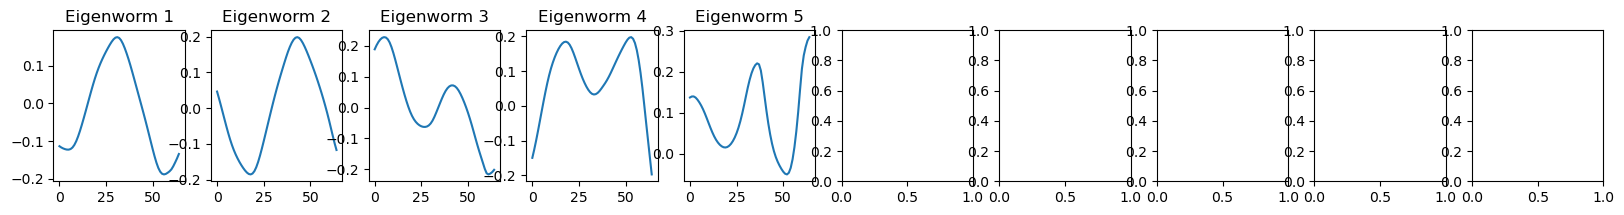

In [60]:
fig1, f1_axs = plt.subplots(ncols=10, nrows=1, constrained_layout=False, figsize=(20,2), dpi=100)
for i, eigenworm in enumerate(pca.components_):
    f1_axs[i].plot(eigenworm)
    f1_axs[i].set_title('Eigenworm ' +str(i+1))
#     f1_axs[0,i].set_xlabel('Time (frames)')
#     f1_axs[0,i].set_ylabel('Signal Amplitude (a.u)')
#         fig.plot(eigenworm)
#     .title('Eingenworm ' +str(i))
#     plt.show()
# i=i+1
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum())
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum(), 'bo')
# f1_axs[i].ylim([0,1])
# f1_axs[i].ylabel('Variance Explained')
# f1_axs[i].xlabel('PC')
# f1_axs[i].xticks(np.arange(5), principalDf.columns)

### Variance explained

In [ ]:
fig=plt.figure(dpi=100)
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.plot(pca.explained_variance_ratio_.cumsum(), 'bo')
plt.ylim([0,1])
plt.ylabel('Variance Explained')
plt.xlabel('PC')
plt.xticks(np.arange(10), principalDf.columns)
print(pca.explained_variance_ratio_)

## Worm reconstruction
After: https://stats.stackexchange.com/questions/229092/how-to-reverse-pca-and-reconstruct-original-variables-from-several-principal-com

In [ ]:
# import numpy as np
# import sklearn.datasets, sklearn.decomposition

# X = sklearn.datasets.load_iris().data
mu = np.mean(data, axis=0)

# pca = sklearn.decomposition.PCA()
# pca.fit(X)
print('data shape is:'+ str(data.shape))

nComp = 2
Xhat = np.dot(pca.transform(data)[:,:nComp], pca.components_[:nComp,:])
Xhat += mu

print(Xhat.shape)

print(Xhat[timepoint,])
plt.plot(Xhat[timepoint,])
plt.xlabel('Body Segment')
plt.show()

In [ ]:
print(principalComponents.shape)
data_projected=pca.inverse_transform(principalComponents)
print(data_projected.shape)
timepoint=100
plt.plot(data[timepoint], 'k',label='data')
plt.plot(data_projected[timepoint], 'r', label='sine')
plt.show()

In [ ]:
plt.plot(principalComponents[timepoint], 'bo')
plt.plot(principalComponents[timepoint], 'b')
plt.show()

In [ ]:
import scipy.integrate as integrate

ot=[-0.09665224,-0.07036113,-0.03568482,-0.01095966,0.00456963,0.01301288
,0.01515584,0.01173461,0.00414439,-0.00591745,-0.01690003,-0.02733173
,-0.03561634,-0.04040833,-0.04201307,-0.04197229,-0.04145336,-0.04097342
,-0.04039757,-0.03901989,-0.03604182,-0.03138896,-0.02541762,-0.01855388
,-0.01105998,-0.0030018,0.0055531,0.01420982,0.02225497,0.02885308
,0.03348408,0.03643765,0.03896626,0.04252434,0.04779851,0.05435349
,0.0601166,0.06159833,0.05643516,0.04708227,0.03764399,0.03031391
,0.02566415,0.02374812,0.02468111,0.02810224,0.0329226,0.03739168
,0.03942093,0.03787015,0.03350831,0.02821021,0.02336129,0.01953443
,0.01680448,0.0150475,0.01410302,0.01383596,0.01414799,0.01496608
,0.01621833,0.01779798,0.01951598,0.02109437,0.02230348,0.02294774
,0.02289075,0.02209662,0.02064323,0.01870233,0.0164995,0.01427403
,0.01225227,0.0106369,0.00960616,0.00929413,0.00959219,0.01024835
,0.01100999,0.01164035,0.01193764,0.01175322,0.01100029,0.00964567
,0.00768182,0.00508159,0.00173786,-0.00261436,-0.0083581,-0.01599204
,-0.02626018,-0.0397085,-0.05526394,-0.0679705,-0.06914133,-0.05546475
,-0.03580964,-0.01800506,-0.00173962,0.02144568]

#conver to array
ot=np.array(ot)
print(ot.shape)
#reshape
ot=ot.reshape(1, -1)
print(ot.shape)
print(ot)
plt.plot(ot[0,:])
plt.title('Omega Centerline')

print(ot_pc.shape)
#plt.plot(pca.inverse_transform(pca.fit_transform(omega_centerline_k)))

In [ ]:
ot_pc=pca.transform(ot)

In [ ]:
ot_pc_inv=pca.inverse_transform(ot_pc)
print(ot_pc_inv.shape)
plt.plot(ot[0,:])
plt.plot(ot_pc_inv[0,:])
plt.show()

# For body segments

In [ ]:
#path='/groups/zimmer/Ulises/code/skeleton_OLD/spline/second_der_np_new.csv'
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-10-48_control_worm1_spline_K.csv'
# has no reversals path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_18-17-47_chemotaxis_worm5_spline_K.csv'
df=pd.read_csv(path, header=None)

print(df.shape)
df.dropna(inplace=True)
print(df.shape)


plt.rcParams["figure.dpi"] = 100

In [ ]:
time=np.arange(10000,14000)#np.arange(30000,34000)
avg_win=1
x=df.loc[time,80].rolling(window=avg_win).mean()
y=df.loc[time,90].rolling(window=avg_win).mean()
# x.dropna(inplace=True)
# y.dropna(inplace=True)
plt.scatter(x,y, c=np.arange(len(x)), s=1, cmap='viridis')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')
plt.colorbar()

In [ ]:
#create dataframe from series
frame = { 'X': x, 'Y': y } 
cross_product_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.nan]
for i, row in enumerate(cross_product_df.iterrows()):
    if i==len(cross_product_df)-1: continue
    r=np.cross([cross_product_df['X'].values[i],cross_product_df['Y'].values[i]], [cross_product_df['X'].values[i+1],cross_product_df['Y'].values[i+1]])
    
    ra.append(r)
cross_product_df['Cross Product']=ra

#optional plotting
plt.plot(cross_product_df.loc[:,'Cross Product'], label='raw')
plt.plot(cross_product_df.index, cross_product_df.loc[:,'Cross Product'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.axhline(y=0, xmin=0, xmax=14000, alpha=0.2, linestyle='--')
plt.title('Cross Product')
plt.legend()

In [ ]:
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[0],y.to_numpy()[0], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')

In [ ]:
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[0],y.to_numpy()[0], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')

In [ ]:
plt.plot(x, label='80')
plt.plot(y, label='90')
plt.legend()

## Plot track

In [49]:
plt.rcParams["figure.dpi"] = 300
lag=-150#-250
ax=track_df.plot.scatter(x='x', y='y', s=0.1, c=-1*cross_product_df.loc[time+lag,'Cross Product'], cmap='bwr')
ax.plot(track_df['x'].head(1),track_df['y'].head(1), 'go', markersize=10)
ax.plot(track_df['x'].tail(1),track_df['y'].tail(1), 'ro', markersize=10)
# ax.set_ylim([19.5,21.5])
# ax.set_xlim([15,17.5])

KeyError: 'Passing list-likes to .loc or [] with any missing labels is no longer supported, see https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#deprecate-loc-reindex-listlike'

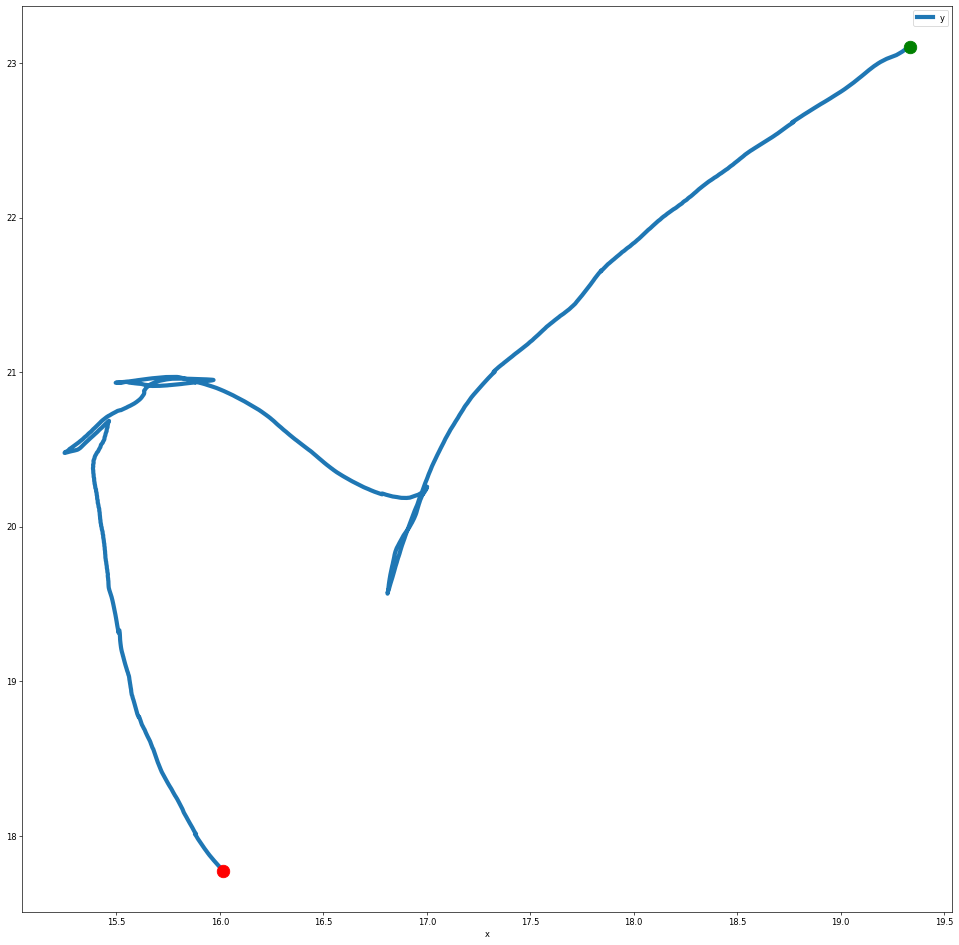

In [37]:
filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_10-10-48_control_worm1-TablePosRecord.txt'
track_df=pd.read_csv(filename)
track_df.rolling(window=10).mean()
track_df=track_df.loc[time,:]
ax=track_df.plot(x='x', y='y', linewidth=5, figsize=(20,20))
plt.plot(track_df['x'].head(1),track_df['y'].head(1), 'go', markersize=15)
plt.plot(track_df['x'].tail(1),track_df['y'].tail(1), 'ro', markersize=15)



In [39]:
cross_product_df.loc[time]

,X,Y,Cross Product
18000,NaN,NaN,NaN
18001,NaN,NaN,nan
18002,NaN,NaN,nan
18003,NaN,NaN,nan
18004,NaN,NaN,nan
...,...,...,...
41995,-0.045949,0.100508,-5.8027422112364585e-05
41996,-0.045483,0.100782,-5.937856175469453e-05
41997,-0.045021,0.101095,-6.0810813807879276e-05
41998,-0.044532,0.101411,-6.36488145112201e-05


## Fictive Data

In [ ]:
#vector
x = np.array([[2,1], [-1,3], [-2,-2]])
y = np.array([[-1,3], [2,2], [2,2]])
np.cross(x, y)

In [ ]:
#coords
x = np.array([[0,0], [2,1], [1,4],[-1,-2]])
y = np.array([[2,1], [1,4], [-1,-2],[2,3]])
np.cross(x, y)

In [ ]:
np.dot(x, y)

In [ ]:
x = np.array([2,-1])
y = np.array([-1,3])
np.cross(x, y)

In [ ]:
x = np.array([-1,3])
y = np.array([2,2])
np.cross(x, y)

In [ ]:
x = np.array([2,2])
y = np.array([-2,-2])
np.cross(x, y)

In [ ]:
x = np.array([2,2])
y = np.array([-3,-3])
np.cross(x, y)

In [ ]:
x = np.array([[0,0], [2,1], [2,2]])
y = np.array([[2,1], [2,2], [-2,-2]])
np.cross(x, y)

## 3D plots

In [ ]:
#3D plottingdiffport matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    '''
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    '''
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:

# Import pandas as pd
import pandas as pd

# Read in the CSV file: df
df=principalDf

# Import figure from bokeh.plotting
from bokeh.plotting import figure
from bokeh.io import push_notebook, show, output_notebook 

# Create the figure: p
p = figure(x_axis_label='PC2', y_axis_label='PC3')

# Plot mpg vs hp by color
p.circle(df['PC2'], df['PC3'], size=10)

# Specify the name of the output file and show the result
output_notebook()
show(p)

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [ ]:
pca.explained_variance_ratio_

In [ ]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [ ]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

In [ ]:
k,d=principalDf

In [ ]:
d

In [ ]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
import re
dir=re.split('-channel',re.split('/',input_filename)[-1])[0]

In [ ]:
dir+'_skeleton_X_coords.csv'

In [ ]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

# PCA for DLC-centerline output

In [4]:
#I CANT DO THIS UNTIL I CALCULATE THE K from the CEnterlines of the centerlines obtained from DLC
import pandas as pd
import glob

In [15]:
path=glob.glob('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/*2020-07-01_18-36-25*34000*h5')
df=pd.read_hdf(path[0], header=None)

df.shape
df.dropna(inplace=True) #Drop NaNs, required otherwise pca.fit_transform(x) does not run
df.fillna(0, inplace=True) #alternative change nans to zeros
features = np.arange(30,95)# Separating out the features (starting bodypart, ending bodypart)
data = df.loc[:, features].values
print(data.shape)

#PCA
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(data)
print(principalComponents.shape)
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2', 'PC3','PC4','PC5'])# 'PC6', 'PC7', 'PC8','PC9','PC10'])

(200001, 0)


ValueError: Found array with 0 feature(s) (shape=(200001, 0)) while a minimum of 1 is required.

In [10]:
path=glob.glob('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/*2020-07-01_18-36-25*34000*h5')


In [16]:
path=glob.glob('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/*2020-07-01_18-36-25*34000*h5')
df=pd.read_hdf(path[0], header=None)

In [18]:
df.values

array([[330.39883423, 317.64227295,   0.42478794, ..., 262.14828491,
        236.97738647,   0.99968374],
       [261.37237549, 274.25857544,   0.99898648, ..., 259.04421997,
        239.301651  ,   0.99981964],
       [262.13571167, 275.40597534,   0.99923426, ..., 259.23666382,
        239.39154053,   0.99980801],
       ...,
       [422.99682617, 401.64520264,   0.99991906, ..., 181.08392334,
        323.75518799,   0.99994314],
       [422.27029419, 401.76245117,   0.99994588, ..., 181.5224762 ,
        323.30410767,   0.99994099],
       [421.7855835 , 401.91882324,   0.99996006, ..., 181.93202209,
        322.70605469,   0.99995357]])